## B7.8 Quantitative Analysis of Damping

In the previous section, we described qualitatively how resistance affects oscillations.  
We now develop a **quantitative criterion** that determines whether a system oscillates or not.

---

### B7.8.1 The Governing Equation

We begin by rewriting the RLC equation in a form that makes comparison to familiar systems clear.

<div style="background-color:#e6f0ff; padding:15px; border-left:6px solid #003366; border-radius:5px;">

**Concept — The Governing Equation**

For an RLC circuit:

$$
L \frac{d^2Q}{dt^2} + R \frac{dQ}{dt} + \frac{1}{C} Q = 0
$$

Divide through by $L$:

$$
\frac{d^2Q}{dt^2} + \frac{R}{L} \frac{dQ}{dt} + \frac{1}{LC} Q = 0
$$

This has the same form as a damped oscillator:

$$
\frac{d^2x}{dt^2} + 2\gamma \frac{dx}{dt} + \omega_0^2 x = 0
$$

where:

$$
2\gamma = \frac{R}{L}, \qquad \omega_0 = \frac{1}{\sqrt{LC}}
$$

</div>

---

### B7.8.2 Solving the Equation

To determine the system behavior, we look for solutions of a standard exponential form.

<div style="background-color:#e0f7fa; padding:15px; border-left:6px solid #006a80; border-radius:5px;">

**Example — Characteristic Equation**

Assume a solution of the form:

$$
Q(t) = e^{rt}
$$

Substitute into the equation:

$$
r^2 + \frac{R}{L} r + \frac{1}{LC} = 0
$$

This is a quadratic equation:

$$
r = -\frac{R}{2L} \pm \sqrt{\left(\frac{R}{2L}\right)^2 - \frac{1}{LC}}
$$

👉 The nature of the solution depends on the term under the square root.

</div>

---

### B7.8.3 Conditions for Different Regimes

The behavior of the system is determined by the discriminant of the quadratic equation.

<div style="background-color:#e6f0ff; padding:15px; border-left:6px solid #003366; border-radius:5px;">

**Concept — Condition for Different Regimes**

Define:

$$
\Delta = \left(\frac{R}{2L}\right)^2 - \frac{1}{LC}
$$

Then:

---

**Underdamped (oscillatory):**

$$
\Delta < 0 \quad \Rightarrow \quad \left(\frac{R}{2L}\right)^2 < \frac{1}{LC}
$$

Oscillations occur with decreasing amplitude.

---

**Critically damped:**

$$
\Delta = 0 \quad \Rightarrow \quad R = 2\sqrt{\frac{L}{C}}
$$

System returns to equilibrium as fast as possible without oscillating.

---

**Overdamped:**

$$
\Delta > 0 \quad \Rightarrow \quad \left(\frac{R}{2L}\right)^2 > \frac{1}{LC}
$$

No oscillations; slow return to equilibrium.

</div>

---

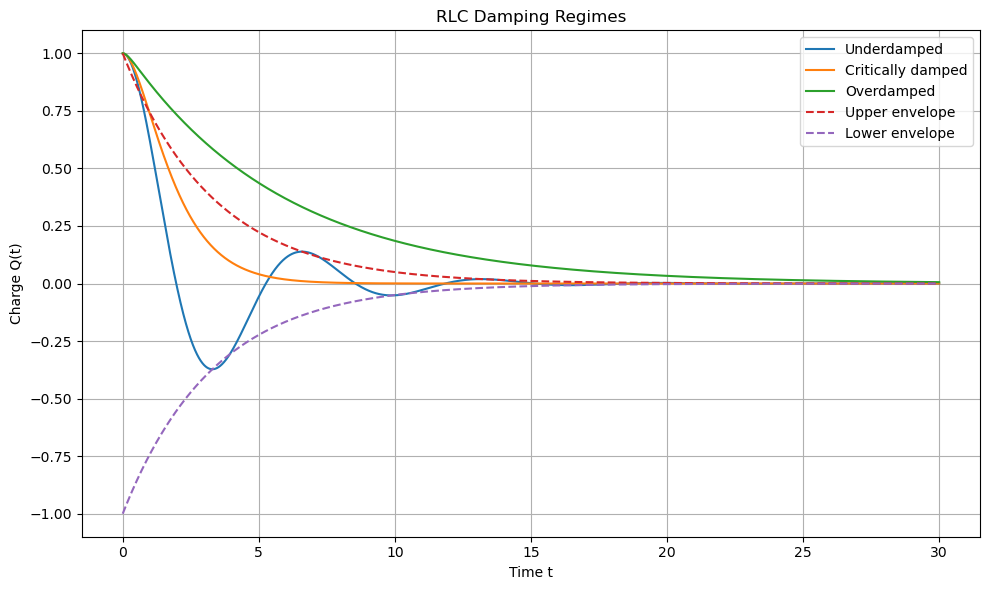

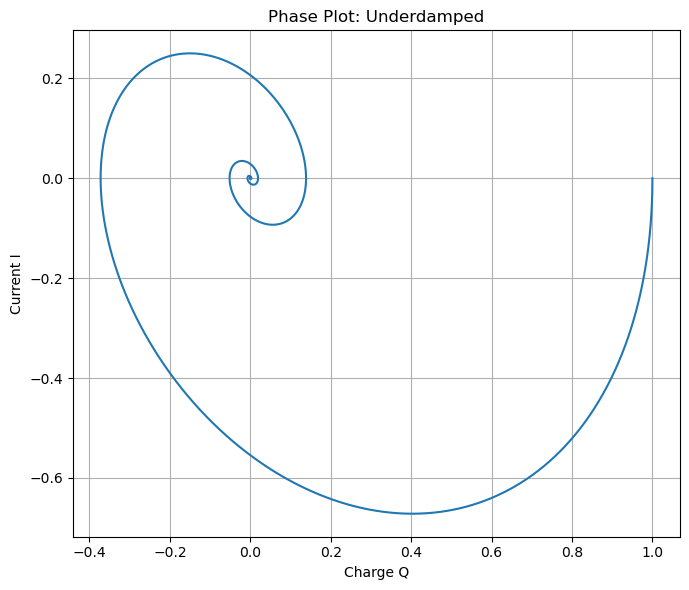

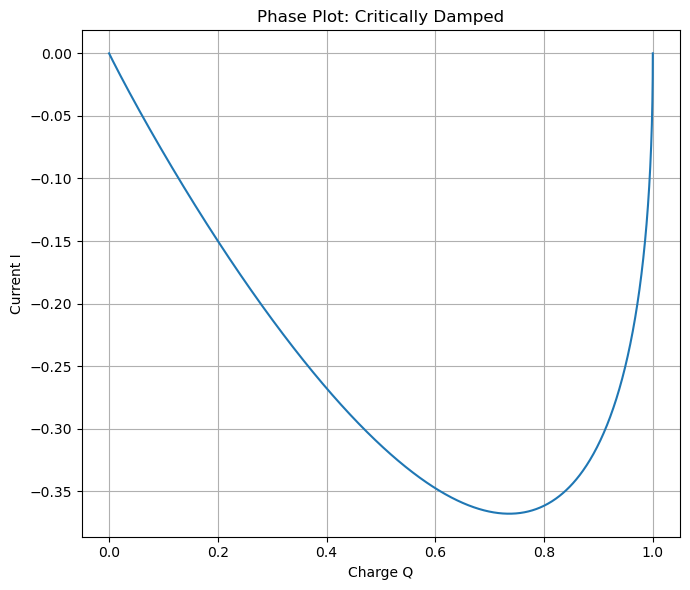

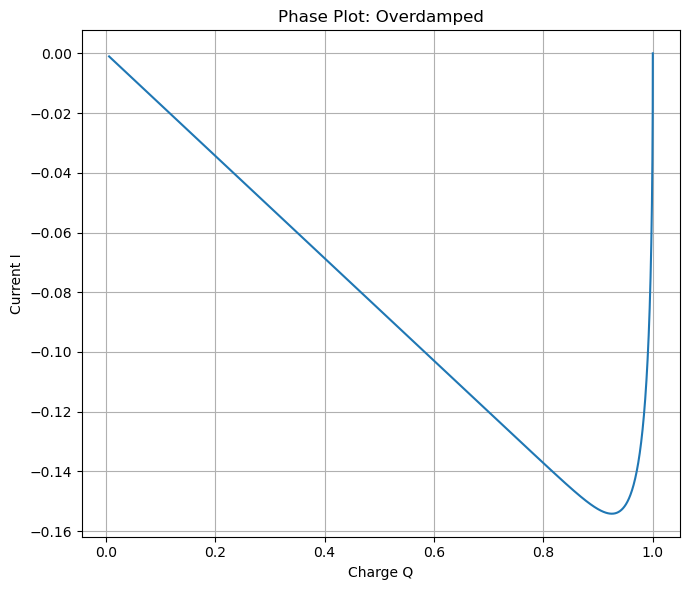

Critical resistance: R_c = 2.0000
Chosen underdamped resistance: R = 0.6000
Chosen critically damped resistance: R = 2.0000
Chosen overdamped resistance: R = 6.0000
Natural angular frequency: omega_0 = 1.0000
Underdamped decay constant: gamma = 0.3000
Underdamped oscillation frequency: omega_d = 0.9539
Underdamped period: T_d = 6.5866


In [2]:
# %reset -f

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# RLC damping illustration:
#   1) Underdamped
#   2) Critically damped
#   3) Overdamped
#
# Equation:
#     L Q'' + R Q' + (1/C) Q = 0
#
# State variables:
#     y = [Q, I], where I = dQ/dt
# ============================================================

# -----------------------------
# Circuit parameters
# -----------------------------
L = 1.0
C = 1.0

R_critical = 2 * np.sqrt(L / C)

# Better choices:
R_under = 0.3 * R_critical   # much more clearly oscillatory
R_crit  = 1.0 * R_critical
R_over  = 3.0 * R_critical

# Initial conditions
Q0 = 1.0
I0 = 0.0

# Time array
t_max = 30.0
dt = 0.002
t = np.arange(0, t_max + dt, dt)

# -----------------------------
# RHS of first-order system
# -----------------------------
def rlc_rhs(state, R, L, C):
    Q, I = state
    dQdt = I
    dIdt = -(R / L) * I - (1 / (L * C)) * Q
    return np.array([dQdt, dIdt], dtype=float)

# -----------------------------
# RK4 solver
# -----------------------------
def solve_rlc(R, L, C, Q0, I0, t):
    y = np.zeros((len(t), 2), dtype=float)
    y[0] = [Q0, I0]

    for n in range(len(t) - 1):
        h = t[n + 1] - t[n]
        yn = y[n]

        k1 = rlc_rhs(yn, R, L, C)
        k2 = rlc_rhs(yn + 0.5 * h * k1, R, L, C)
        k3 = rlc_rhs(yn + 0.5 * h * k2, R, L, C)
        k4 = rlc_rhs(yn + h * k3, R, L, C)

        y[n + 1] = yn + (h / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

    return y[:, 0], y[:, 1]

# -----------------------------
# Solve cases
# -----------------------------
Q_under, I_under = solve_rlc(R_under, L, C, Q0, I0, t)
Q_crit,  I_crit  = solve_rlc(R_crit,  L, C, Q0, I0, t)
Q_over,  I_over  = solve_rlc(R_over,  L, C, Q0, I0, t)

# -----------------------------
# Envelope for underdamped case
# -----------------------------
gamma_under = R_under / (2 * L)
envelope = Q0 * np.exp(-gamma_under * t)

# -----------------------------
# Plot: time behavior
# -----------------------------
plt.figure(figsize=(10, 6))
plt.plot(t, Q_under, label='Underdamped')
plt.plot(t, Q_crit, label='Critically damped')
plt.plot(t, Q_over, label='Overdamped')
plt.plot(t, envelope, '--', label='Upper envelope')
plt.plot(t, -envelope, '--', label='Lower envelope')

plt.xlabel('Time t')
plt.ylabel('Charge Q(t)')
plt.title('RLC Damping Regimes')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# Phase plot: underdamped
# -----------------------------
plt.figure(figsize=(7, 6))
plt.plot(Q_under, I_under)
plt.xlabel('Charge Q')
plt.ylabel('Current I')
plt.title('Phase Plot: Underdamped')
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# Phase plot: critically damped
# -----------------------------
plt.figure(figsize=(7, 6))
plt.plot(Q_crit, I_crit)
plt.xlabel('Charge Q')
plt.ylabel('Current I')
plt.title('Phase Plot: Critically Damped')
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# Phase plot: overdamped
# -----------------------------
plt.figure(figsize=(7, 6))
plt.plot(Q_over, I_over)
plt.xlabel('Charge Q')
plt.ylabel('Current I')
plt.title('Phase Plot: Overdamped')
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# Useful quantities
# -----------------------------
omega0 = 1 / np.sqrt(L * C)
gamma = R_under / (2 * L)
omega_d = np.sqrt(omega0**2 - gamma**2)

print(f"Critical resistance: R_c = {R_critical:.4f}")
print(f"Chosen underdamped resistance: R = {R_under:.4f}")
print(f"Chosen critically damped resistance: R = {R_crit:.4f}")
print(f"Chosen overdamped resistance: R = {R_over:.4f}")
print(f"Natural angular frequency: omega_0 = {omega0:.4f}")
print(f"Underdamped decay constant: gamma = {gamma:.4f}")
print(f"Underdamped oscillation frequency: omega_d = {omega_d:.4f}")
print(f"Underdamped period: T_d = {2*np.pi/omega_d:.4f}")

---
## B7.8.4 Interpreting Phase Plots

In addition to time-based graphs, we also showed an often useful to representation the behavior of an RLC circuit using a **phase plot**, where we graph:

$$
I \;\text{vs.}\; Q
$$

Since current is related to charge by

$$
I = \frac{dQ}{dt},
$$

each point on this plot represents the **state of the system at a given instant**:
- $Q$ tells us “where the system is”
- $I$ tells us “how it is changing”

As time progresses, the system traces out a **trajectory in the $(Q, I)$ plane**, called phase space.

---

### What Phase Plots Show

A phase plot does not explicitly show time. Instead, it shows:

- The relationship between a variable and its rate of change  
- The overall structure of motion in a single curve  

👉 This makes it possible to identify qualitative behavior immediately:
- Oscillatory vs non-oscillatory motion  
- Fast vs slow return to equilibrium  
- Energy exchange between different forms  

---

### Underdamped Case — Spiral Toward the Origin

For the underdamped case:

- The system oscillates while gradually losing energy  

In the phase plot:
- The trajectory forms a **spiral inward**

**Interpretation:**

- Each loop corresponds to one oscillation  
- The decreasing radius reflects **energy dissipation**  
- Motion alternates between:
  - Large $Q$, small $I$ → energy mostly electric  
  - Small $Q$, large $I$ → energy mostly magnetic  

👉 The spiral captures both **oscillation and decay** in a single picture.

---

### Critically Damped Case — Direct Approach

For the critically damped case:

- The system returns to equilibrium without oscillating  
- It does so as quickly as possible  

In the phase plot:
- The trajectory moves **directly toward the origin**  
- There are no loops or spirals  

**Interpretation:**

- The system smoothly approaches equilibrium  
- There is no back-and-forth energy exchange  
- The path represents the **optimal balance** between inertia and damping  

---

### Overdamped Case — Slow Approach

For the overdamped case:

- The system does not oscillate  
- It returns to equilibrium more slowly  

In the phase plot:
- The trajectory approaches the origin gradually  
- It does not loop or spiral  

**Interpretation:**

- Strong damping suppresses motion  
- Energy is dissipated before oscillation can occur  
- The system is “over-restrained,” leading to slow evolution  

---

### Why Phase Plots Are Useful

Phase plots provide a powerful way to understand system behavior:

- They combine **position and rate of change** in one view  
- They clearly distinguish between:
  - Oscillatory motion (spirals)  
  - Non-oscillatory motion (direct paths)  

- They visualize energy flow:
  - Horizontal extremes (large $Q$) → electric energy  
  - Vertical extremes (large $I$) → magnetic energy  

- They reveal the **global behavior** of the system, not just snapshots in time  

---

### Key Insight

A phase plot shows how the system moves through its possible states:

> Instead of tracking motion as a function of time, we see the **structure of the motion itself**.

This perspective provides a deeper understanding of RLC circuits as **dynamical systems**, connecting circuit behavior to broader ideas used throughout physics.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

### B7.8.5 Interpreting the Damping Regimes

Having established the mathematical conditions for each regime, we now interpret what these results mean physically.

<div style="background-color:#ffe6e6; padding:15px; border-left:6px solid #990000; border-radius:5px;">

**Danger Zone — Interpreting the Critical Case**

Critical damping is not about “maximum resistance.”

- Too little resistance → oscillations  
- Too much resistance → slow response  

👉 Critical damping is the **exact balance point** between oscillation and overdamping.

</div>

---

### B7.8.6 Damped Oscillation Frequency

When the system is underdamped, it still oscillates — but not at the natural frequency of the undamped system.

<div style="background-color:#e0f7fa; padding:15px; border-left:6px solid #006a80; border-radius:5px;">

**Example — Damped Oscillation Frequency**

For the underdamped case, the oscillation frequency becomes:

$$
\omega = \sqrt{\omega_0^2 - \gamma^2}
$$

where:

$$
\gamma = \frac{R}{2L}
$$

👉 Resistance reduces the oscillation frequency.

</div>

---

### B7.8.7 Applying the Criteria

We can now use the derived conditions to predict system behavior.

<div style="background-color:#e8f5e9; padding:15px; border-left:6px solid #006633; border-radius:5px;">

**Box Activity 1 — Identifying Critical Resistance**

Given $L$ and $C$, determine the resistance that produces critical damping.

<details>
<summary>Solution</summary>

Set:

$$
\left(\frac{R}{2L}\right)^2 = \frac{1}{LC}
$$

Solving:

$$
R = 2\sqrt{\frac{L}{C}}
$$

</details>

</div>

---

<div style="background-color:#e8f5e9; padding:15px; border-left:6px solid #006633; border-radius:5px;">

**Box Activity 2 — Predicting Behavior**

A circuit has:

- Small $R$
- Fixed $L$ and $C$

1. Will the system oscillate?  
2. How will increasing $R$ change the behavior?

<details>
<summary>Solution</summary>

1. Yes — it is underdamped  
2. Increasing $R$ reduces oscillations and can eventually eliminate them  

</details>

</div>

---

This section completes the transition from **qualitative understanding** to **predictive analysis**:

> You can now determine exactly when a circuit will oscillate and how resistance controls its behavior.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">